In [6]:
from pathlib import Path
import datetime
import json

import torch
import torch.nn.functional as F
from jaxtyping import Int, Float
import matplotlib.pyplot as plt

# custom utils
from muutils.misc import shorten_numerical_to_str
from trnbl import TrainingManager
from zanj import ZANJ

# from trnbl.loggers.local import LocalLogger
from trnbl.loggers.tensorboard import TensorBoardLogger
from trnbl.loggers.wandb import WandbLogger


from attention_motifs.train_util import contrastive_loss
from attention_motifs.dataset.dataset import CollectedAttentionPatternDataloader
from attention_motifs.dataset.util import AttentionPatternMetadata
from attention_motifs.vit_ae import VitAEConfig, VitAE
from attention_motifs.dataset.dataset import DatasetMock
from attention_motifs.train import get_dataset, set_up_model, train, eval_plots
from attention_motifs.dataset.dataset import DataloaderMock


In [7]:
# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
ACTIVATIONS_PATH = "../data/activations/medium"
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE: int = 10
N_TRAIN_BATCHES: int = 6000
MODEL_CONFIG: VitAEConfig = VitAEConfig(
	d_latent=128,
	num_epochs=1,
)

{
  "n_total_samples": 406808,
  "n_prompts": 599,
  "n_datasets": 9,
  "config": {
    "prompts_config": {
      "name": "pile_50",
      "source_path": "../data/pile_50.jsonl",
      "char_len_min": 64,
      "char_len_max": 256
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 16,
    "prompt_token_len_tolerance": 16,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(52256, 64, 64)",
    "(289408, 48, 48)",
    "(6648, 80, 80)",
    "(42464, 32, 32)",
    "(11560, 16, 16)",
    "(2024, 96, 96)",
    "(288, 112, 112)",
    "(1872, 128, 128)",
    "(288, 144, 144)"
  ]
}
Train loader: 6000 batches, 60000 samples
AttentionPatternMetadata(model_name='pythia-14m', idx_layer=3, idx_head=0, n_ctx=80, prompt_hash=2840472775)


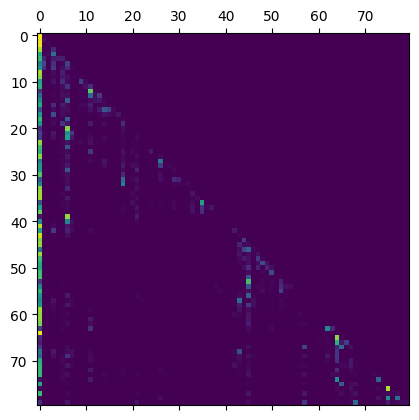

In [9]:
TRAIN_LOADER: DataloaderMock
TRAIN_LOADER, DATASET_INFO, x_mat, x_meta = get_dataset(
	activations_path=ACTIVATIONS_PATH,
	batch_size=BATCH_SIZE,
	n_train_batches=N_TRAIN_BATCHES,
)

In [10]:
MODEL, OPTIMIZER, LR_SCHEDULER = set_up_model(
	config=MODEL_CONFIG,
	model_cls=VitAE,
	device=DEVICE,
)


model has 367762 (368K) parameters


In [11]:
# init logger
LOGGER: TensorBoardLogger = TensorBoardLogger(
	log_dir=Path("tb-logs-convAE"),
	name="vit-ae" + datetime.datetime.now().strftime("-%Y-%m-%d-%H-%M-%S"),
	train_config=dict(
		model_config=MODEL.zanj_model_config.serialize(),
		dataset_info=DATASET_INFO,
		model_str=str(MODEL),
		device=str(DEVICE),
	),
)

MODEL = train(
	logger=LOGGER,
	device=DEVICE,
	model=MODEL,
	optimizer=OPTIMIZER,
	lr_scheduler=LR_SCHEDULER,
	train_loader=TRAIN_LOADER,
)

starting training manager initialization
initialized training manager


epoch 1/1:   0%|          | 0/6000 [00:00<?, ? batches/s]F:\projects\attention-motifs\attention_motifs\train_util.py:73: UserWarning: No positive pairs found in batch
  warnings.warn("No positive pairs found in batch")
epoch 1/1: 100%|██████████| 6000/6000 [05:14<00:00, 19.09 batches/s]

training complete


AttentionPatternMetadata(model_name='pythia-14m', idx_layer=3, idx_head=0, n_ctx=80, prompt_hash=2840472775)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


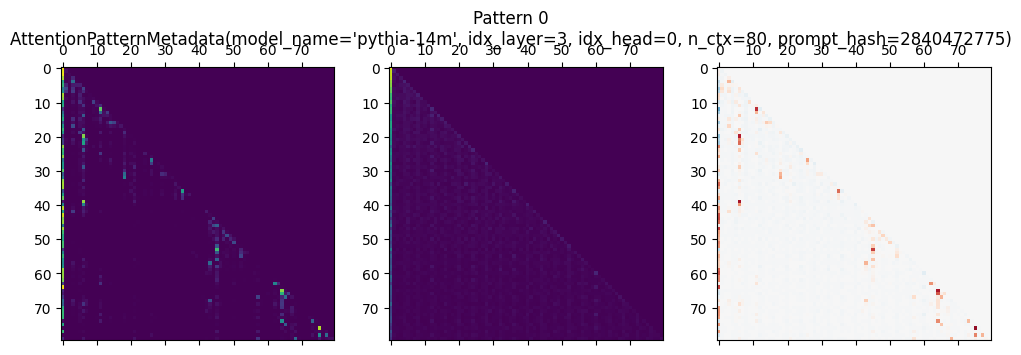

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=5, idx_head=22, n_ctx=80, prompt_hash=301259350)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


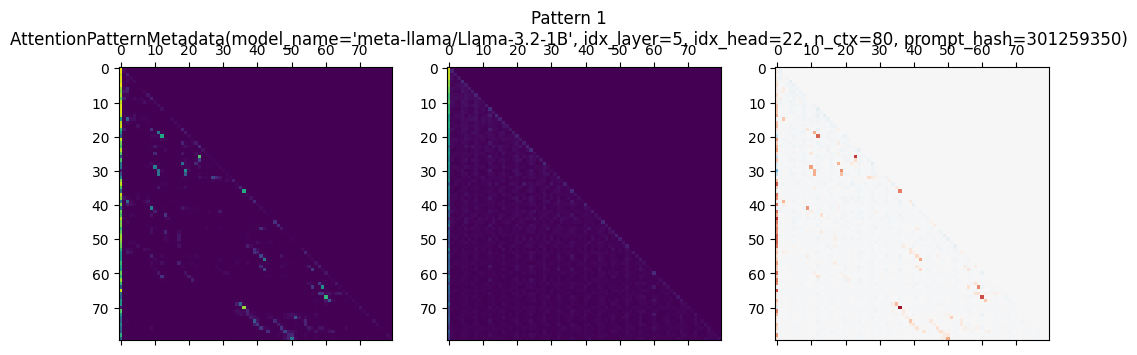

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=7, idx_head=27, n_ctx=80, prompt_hash=3744172075)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


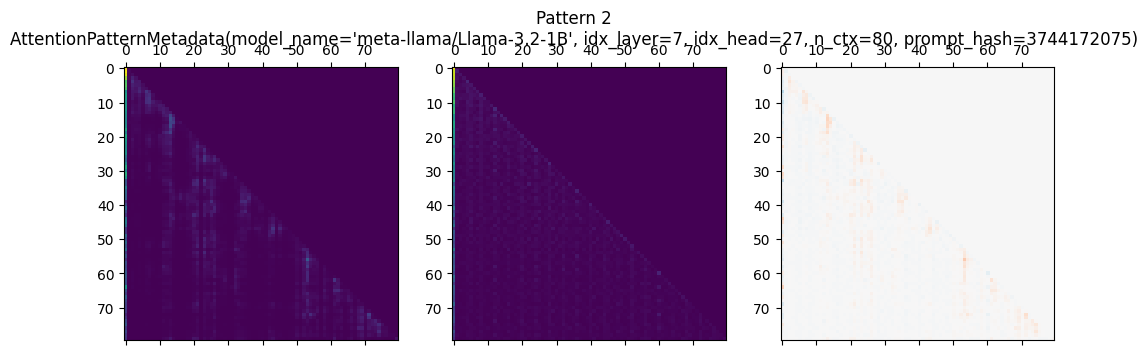

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=0, idx_head=8, n_ctx=80, prompt_hash=13867974)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


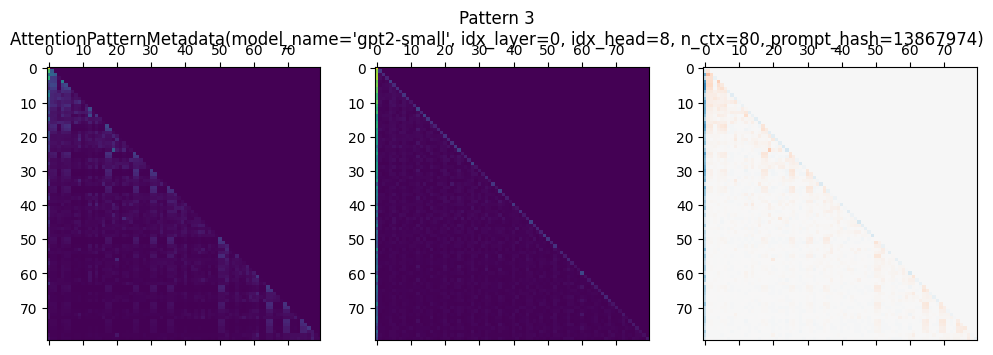

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=1, idx_head=10, n_ctx=80, prompt_hash=790515033)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


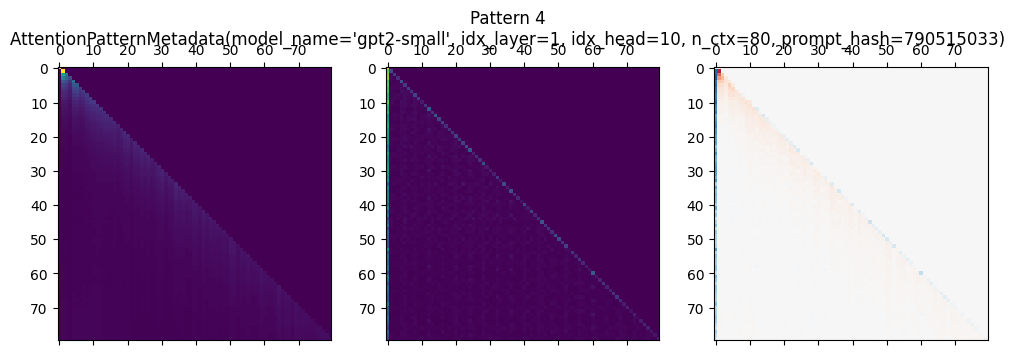

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=1, idx_head=1, n_ctx=80, prompt_hash=3845919505)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


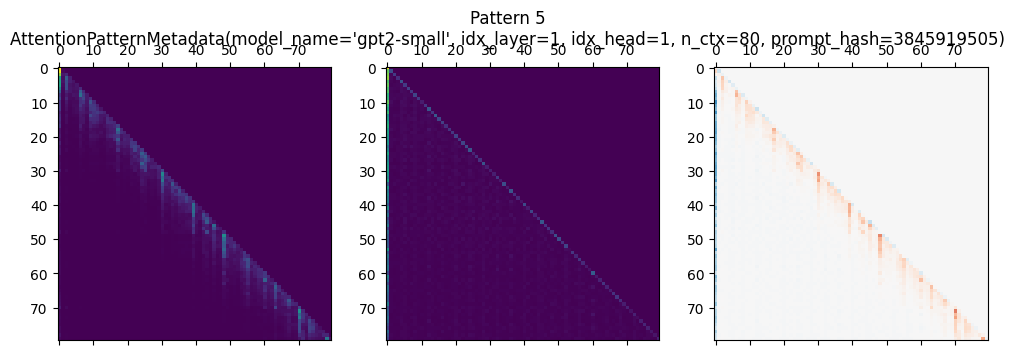

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=11, idx_head=0, n_ctx=80, prompt_hash=3701133989)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


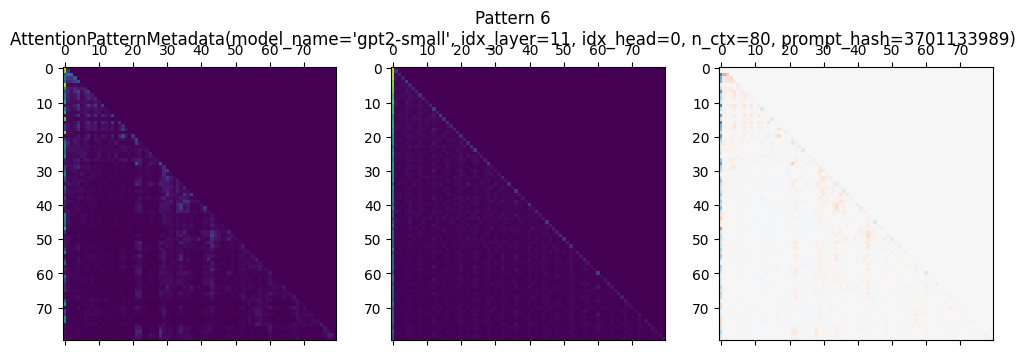

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=0, idx_head=31, n_ctx=80, prompt_hash=3744172075)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


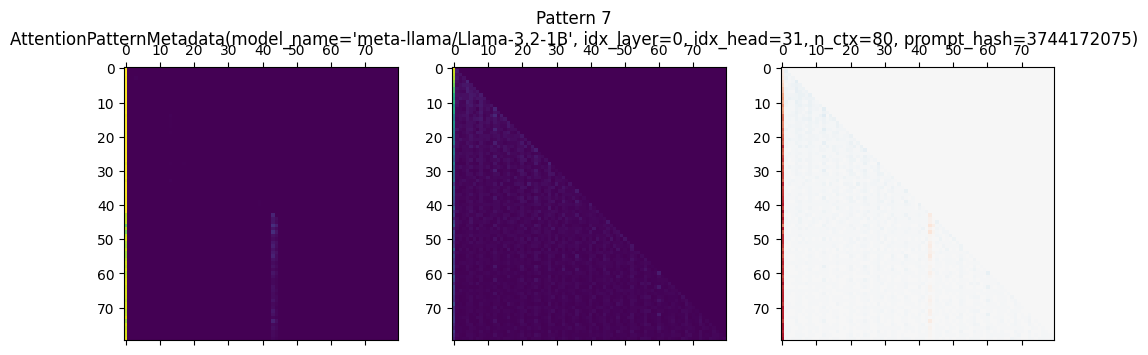

AttentionPatternMetadata(model_name='pythia-14m', idx_layer=5, idx_head=3, n_ctx=80, prompt_hash=817594355)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


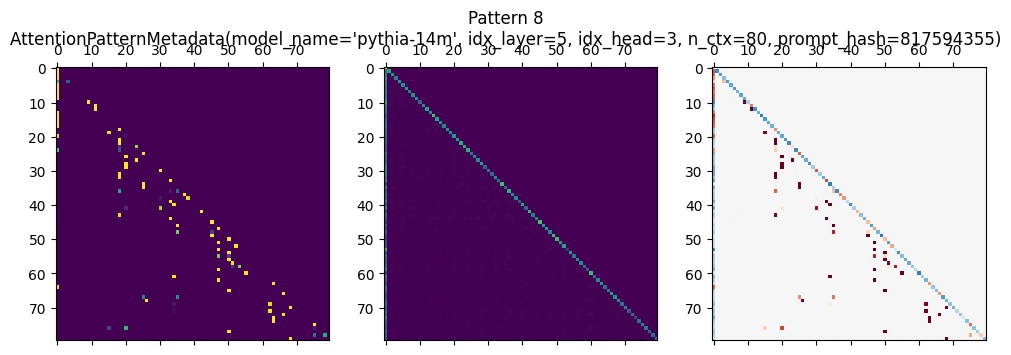

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=8, idx_head=6, n_ctx=80, prompt_hash=4139186876)
patterns.shape = torch.Size([10, 80, 80])
x_latent.shape = torch.Size([10, 128])
x_recon.shape = torch.Size([10, 1, 80, 80])


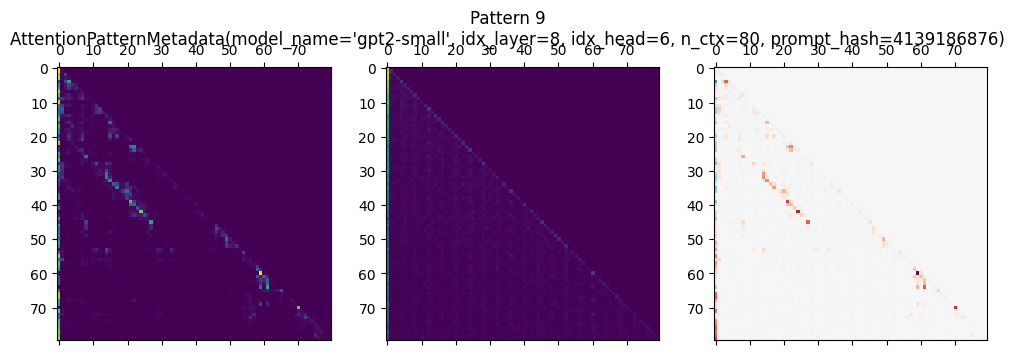

In [12]:
eval_plots(
	model=MODEL,
	patterns=x_mat,
	metadata=x_meta,
	device=DEVICE,
)